### Questao 1.1: Quantas instâncias e quantos atributos existem?

In [1]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.shape)

(119390, 32)

### Questao 1.2: Quais atributos são numéricos e quais são categóricos?

In [2]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.dtypes)


def verifyAtribute(df):
    countC = 0
    countN = 0

    for column in df.columns:
        if df[column].dtype != 'str' and df[column].nunique() != 2:
            countN += 1
        else:
            countC += 1

    return countC, countN

categoricos, numericos = verifyAtribute(df)

print("Categóricos:", categoricos)
print("Numéricos:", numericos)



hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

Categóricos: 14
Numéricos: 18


### Questao 1.3: Quais atributos são binários?

In [14]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyBi(df):
    result = []

    for column in df.columns:
        if df[column].nunique() == 2:
            result.append({
                'Attribute': column,
                'Values': df[column].dropna().unique()
            })

    return result

display(pd.DataFrame(verifyBi(df)))

,Attribute,Values
0,hotel,"[Resort Hotel, City Hotel]"
1,is_canceled,"[0, 1]"
2,is_repeated_guest,"[0, 1]"


### Questao 1.4: Quais atributos representam características da reserva, do cliente, da estadia e do hotel?

In [4]:
##Pulei por enquanto


### Questao 2.5: Existem valores faltantes? Em quais atributos e em que quantidade? 

In [15]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def valueOff(df):
    result = []

    for column in df.columns:
        null_count = df[column].isnull().sum()

        if null_count != 0:
            result.append({
                'Attribute': column,
                'Null Values': null_count
            })

    return result


display(pd.DataFrame(valueOff(df)))

,Attribute,Null Values
0,children,4
1,country,488
2,agent,16340
3,company,112593


### Questao 2.6: Existem registros duplicados? 

In [19]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.duplicated().sum()

np.int64(31994)

### Questao 2.7: Quais atributos possuem grande quantidade de valores distintos?

In [12]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyDistinct(df):
    result = []
    for column in df.columns:
        if df[column].nunique() >= 100:
            result.append({'atrubute': column, 'distinc values': df[column].nunique()}) 
    return result

display(pd.DataFrame(verifyDistinct(df)))


,atrubute,distinc values
0,lead_time,479
1,country,177
2,agent,333
3,company,352
4,days_in_waiting_list,128
5,adr,8879
6,reservation_status_date,926


### Questao 2.8: Quais problemas de qualidade precisam ser considerados antes de uma análise posterior?
Resposta: Entre esses casos, acredito que devam ser tartados: 
- Valores Nulos(NaN), podem vir a prejudicar a analise desses dados. 
- Valores com linhas duplicadas, podem vir a distorcer as analises.
- Os atributos com valores extremos que podem significar a presenca de outliers.

### Questao 3: Calcule média, mediana, mínimo, máximo, quartis, amplitude, IQR e desvio padrão para os principais atributos numéricos.
Nesse arquivo eu vou fazer duas funcoes, uma pra pegar exatamente as colunas especificas apresentadas e outra para usar em qualquer csv generica, pegando e calculando para todas as colunas


In [1]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.describe()

#Funcao Especifica
def func1(df):
    attributes = [
        'lead_time',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'babies',
        'previous_cancellations',
        'booking_changes',
        'days_in_waiting_list',
        'adr',
        'total_of_special_requests'
    ]
    stats = df[attributes].describe()
    stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
    return stats

display(func1(df))

#Funcao generica
# def func2(df):
#     stats = df.describe()
#     stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
#     stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
#     return stats

# display(func2(df))

    

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,0.087118,0.221124,2.321149,101.831122,0.571363
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,0.844336,0.652306,17.594721,50.535790,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,1.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5400.000000,5.000000
amplitude,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5406.380000,5.000000
IQR,142.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.710000,1.000000


### Gráfico 1 – Distribuição do tempo de antecedência das reservas

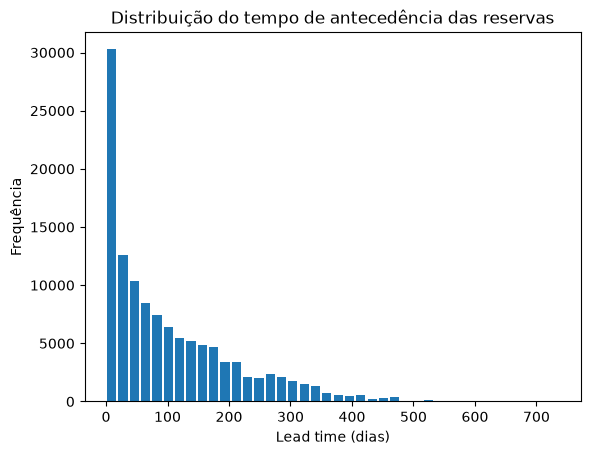

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

%matplotlib inline

df['lead_time'].plot.hist(
    bins=40,
    rwidth=0.8
)

plt.title('Distribuição do tempo de antecedência das reservas')
plt.xlabel('Lead time (dias)')
plt.ylabel('Frequência')

plt.show()

#### 4.1 - Em que faixa de antecedência está concentrada a maior parte das reservas?

Resposta: A maior parte das reservas está concentrada entre 0 e 100 dias de antecedência.

#### 4.2 - A distribuição parece simétrica ou assimétrica?

Resposta: A distribuição é assimétrica à direita (assimetria positiva), pois a maioria das reservas possui baixa antecedência, enquanto a cauda se estende para valores mais elevados.

#### 4.3 - Existe uma cauda longa para valores elevados?

Resposta: Sim. Existe uma cauda longa que se estende para valores elevados de *lead time*, embora essas reservas ocorram com baixa frequência.

#### 4.4 - Há indícios de valores extremos?

Resposta: Sim. As reservas com valores de *lead time* muito elevados, especialmente acima de 500 dias, podem representar valores extremos. A alta frequência entre 0 e 20 dias não indica um valor extremo, mas sim a faixa em que há maior concentração de reservas.

#### 4.5 - O que o formato sugere sobre o planejamento das reservas?

Resposta: O formato sugere que a maioria dos clientes prefere fazer reservas com pouca antecedência. Entretanto, há um grupo menor de clientes que planeja suas reservas com muita antecedência.

### Gráfico 2 – Distribuição do preço médio diário (ADR)

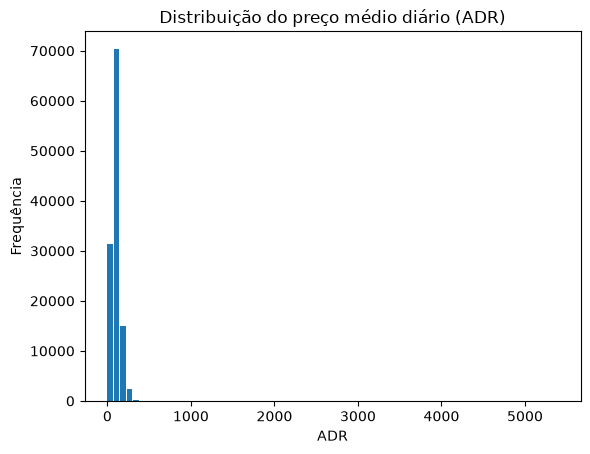

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df['adr'].plot.hist(
    bins=70,
    rwidth=0.9
)

plt.title('Distribuição do preço médio diário (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequência')

plt.show()

# isso aqui foi so pra conferir, nao eh necessario nao
# display(df['adr'].describe())
# display(df['adr'].sort_values(ascending=False).head(20))

#### 4.6 - Em qual faixa de preço está concentrada a maior parte das reservas?
Resposta: A maior concentracao esta ali por volta de 0 e 200 aproximadamente.

#### 4.7 - A distribuição apresenta assimetria?
Resposta: Sim, a distribuicao apresenta assimetria positiva, devido a alta concentracao a direita.

#### 4.8 - Existem valores muito afastados da concentração principal?
Resposta: Sim. Embora a maioria dos valores de ADR esteja concentrada nas primeiras faixas do histograma, existem poucos registros muito distantes dessa concentração, incluindo um valor próximo de 5.400. Esses registros podem representar possíveis valores extremos.

#### 4.9 - A média parece representar bem o preço típico? Compare com a mediana.
Resposta: A média do ADR é aproximadamente 101,83, enquanto a mediana é 94,58. A média é maior porque os valores extremos elevados a puxam para cima. Assim, a mediana representa melhor o preço típico, pois é menos influenciada por valores extremos.

#### 4.10 - Que cuidados devem ser tomados ao utilizar ADR em análises posteriores?
Resposta: Deve-se considerar a forte assimetria da distribuição e investigar os valores extremos para verificar se representam casos reais ou erros.

### Gráfico 3 – Boxplot do ADR por tipo de hotel

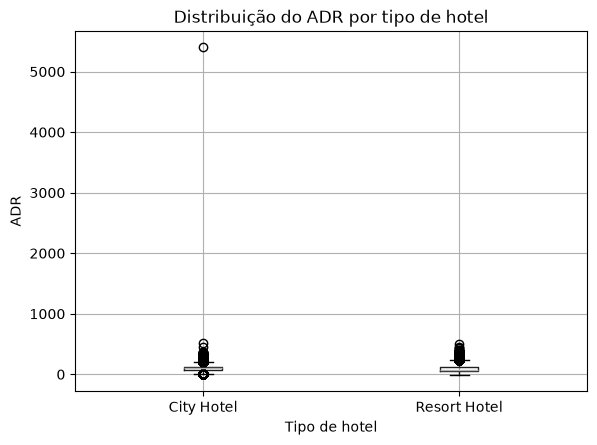

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df.boxplot(
    column='adr',
    by='hotel'
)

plt.title('Distribuição do ADR por tipo de hotel')
plt.suptitle('')

plt.xlabel('Tipo de hotel')
plt.ylabel('ADR')

plt.show()

## grupo teste
# df.groupby('hotel')['adr'].describe()
# df.nlargest(10, 'adr')[['hotel', 'adr']]

#### 4.11 - Qual tipo de hotel apresenta maior mediana?
Resposta: O City Hotel

#### 4.12 - Qual apresenta maior dispersão?
Resposta: O Resort Hotel

#### 4.13 - Os intervalos interquartis são semelhantes?
Resposta: Não. O Resort Hotel apresenta um intervalo interquartil maior.

#### 4.14 - Há mais valores extremos em um dos grupos?
Resposta: Sim, no City Hotel tem mais possiveis valores extremos.

#### 4.15 - Os preços dos dois hotéis apresentam comportamentos semelhantes?
Resposta: Aparentemente sim, ambas possuem assimetria positiva.

### Gráfico 4 – Cancelamentos por tipo de hotel

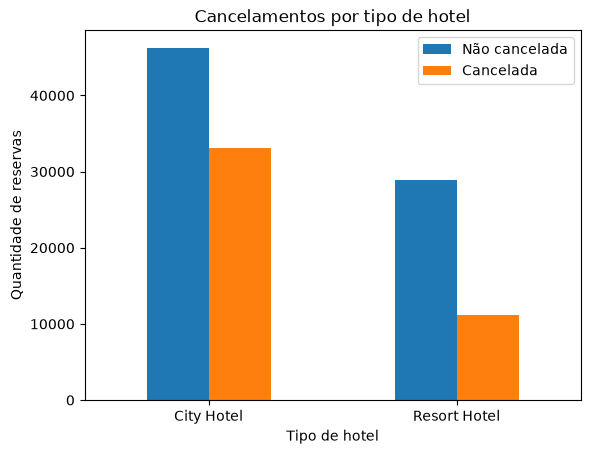

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

cancellations = df.groupby(
    ['hotel', 'is_canceled']
).size().unstack()

cancellations.plot(
    kind='bar'
)

plt.title('Cancelamentos por tipo de hotel')
plt.xlabel('Tipo de hotel')
plt.ylabel('Quantidade de reservas')
plt.legend(['Não cancelada', 'Cancelada'])
plt.xticks(rotation=0)

plt.show()

#### 4.16 - Qual hotel possui maior número absoluto de cancelamentos?
Resposta: O city Hotel possui um numero maior de cancelamentos.

#### 4.17 - Qual apresenta maior proporção de cancelamentos?\
Resposta: O City Hotel também apresenta a maior proporção de cancelamentos.

#### 4.18 - Por que apenas o número absoluto pode levar a uma interpretação equivocada?
Resposta: O número absoluto pode levar a uma interpretação equivocada porque os hotéis possuem quantidades diferentes de reservas. Como o City Hotel possui mais reservas no total, é esperado que também possa apresentar mais cancelamentos.

#### 4.19 - O comportamento de cancelamento parece diferir entre os hotéis?
Resposta: Sim. O City Hotel apresenta maior quantidade e maior proporção de cancelamentos. Isso indica que o cancelamento é mais frequente no City Hotel do que no Resort Hotel.

### Gráfico 5 – Cancelamento e antecedência da reserva

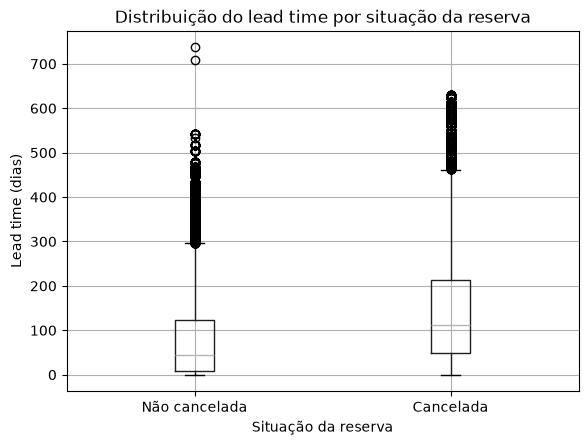

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df.boxplot(
    column='lead_time',
    by='is_canceled'
)

plt.title('Distribuição do lead time por situação da reserva')
plt.suptitle('')

plt.xlabel('Situação da reserva')
plt.ylabel('Lead time (dias)')

plt.xticks(
    [1, 2],
    ['Não cancelada', 'Cancelada']
)

plt.show()

#### 4.20 — Qual grupo apresenta maior mediana de antecedência?

Resposta: As reservas canceladas apresentam a maior mediana de antecedência, com aproximadamente 113 dias. Nas reservas não canceladas, a mediana é de 45 dias.

#### 4.21 — Qual grupo apresenta maior dispersão?

Resposta: As reservas canceladas apresentam maior dispersão. Seu intervalo interquartil é de aproximadamente 166 dias, enquanto o das reservas não canceladas é de 115 dias.

#### 4.22 — As reservas canceladas parecem ter sido feitas com maior antecedência?

Resposta: Sim. As reservas canceladas possuem mediana e quartis mais elevados, indicando que, em geral, foram realizadas com maior antecedência.

#### 4.23 — O gráfico fornece evidência de uma possível relação entre antecedência e cancelamento?

Resposta: Sim. O gráfico mostra que as reservas canceladas tendem a apresentar valores maiores de `lead_time`. Isso sugere uma possível associação entre maior antecedência e cancelamento, mas o boxplot sozinho não comprova uma relação de causa e efeito.

#### 4.24 — Que hipótese sobre cancelamentos poderia ser investigada depois?

Resposta: Uma hipótese a ser investigada é que reservas feitas com maior antecedência apresentam maior probabilidade de cancelamento. Essa hipótese pode ser avaliada comparando as taxas de cancelamento por faixas de `lead_time` ou utilizando um modelo estatístico.

### Gráfico 6 – Demanda ao longo do ano

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,3736,2193
February,4965,3103
March,6458,3336
April,7480,3609
May,8232,3559
June,7894,3045
July,8088,4573
August,8983,4894
September,7400,3108


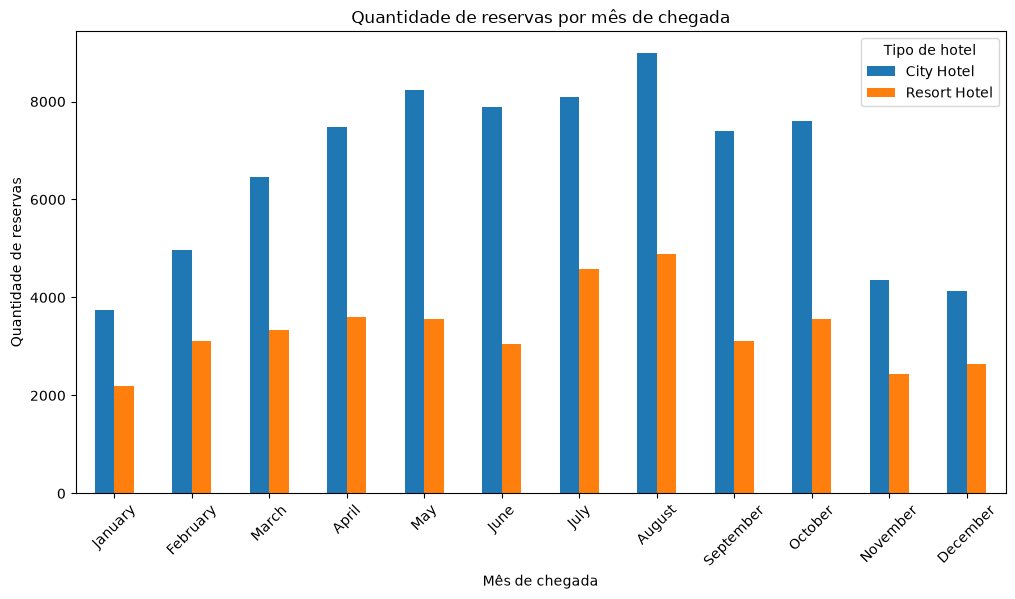

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_demand = (
    df.groupby(['arrival_date_month', 'hotel'])
      .size()
      .unstack()
      .reindex(month_order)
)

display(monthly_demand)

monthly_demand.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Quantidade de reservas por mês de chegada')
plt.xlabel('Mês de chegada')
plt.ylabel('Quantidade de reservas')

plt.xticks(rotation=45)

plt.legend(title='Tipo de hotel')

plt.show()

### Gráfico 7 – Relação entre antecedência e preço


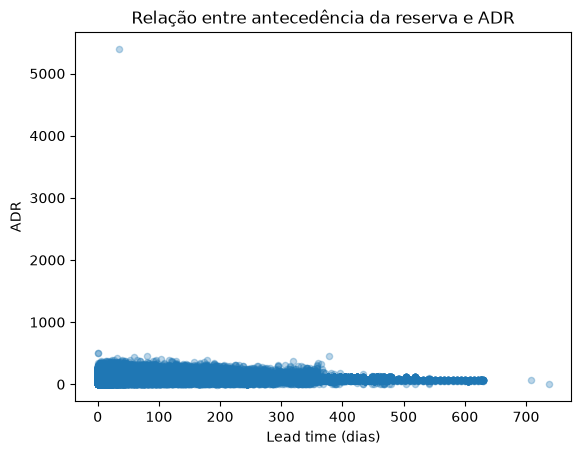

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df.plot.scatter(
    x='lead_time',
    y='adr',
    alpha=0.3
)

plt.title('Relação entre antecedência da reserva e ADR')
plt.xlabel('Lead time (dias)')
plt.ylabel('ADR')

plt.show()

### Gráfico 8 – Relação entre duração da estadia e preço

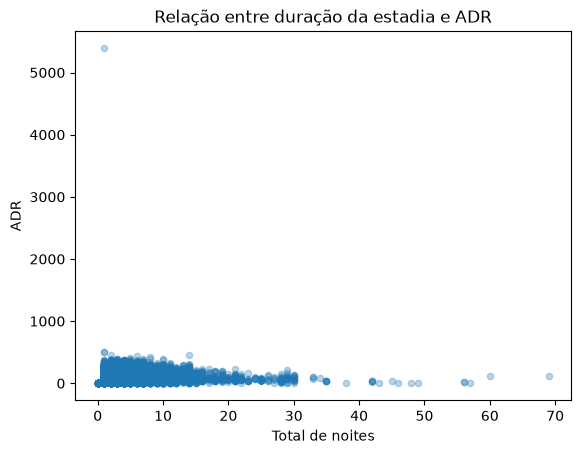

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

# Cria a nova coluna com o total de noites
df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

# Scatter plot
df.plot.scatter(
    x='total_nights',
    y='adr',
    alpha=0.3
)

plt.title('Relação entre duração da estadia e ADR')
plt.xlabel('Total de noites')
plt.ylabel('ADR')

plt.show()

### Gráfico 9 – Solicitações especiais por perfil de cliente

customer_type
Contract           0.728901
Group              0.644714
Transient          0.631582
Transient-Party    0.329327
Name: total_of_special_requests, dtype: float64

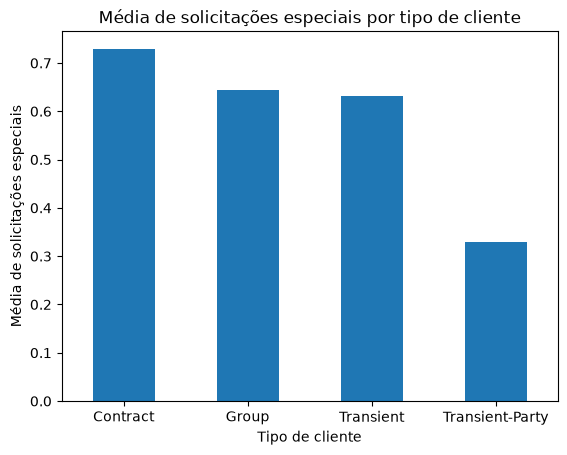

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

special_requests_mean = (
    df.groupby('customer_type')['total_of_special_requests']
      .mean()
)

display(special_requests_mean)

special_requests_mean.plot(
    kind='bar'
)

plt.title('Média de solicitações especiais por tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Média de solicitações especiais')

plt.xticks(rotation=0)

plt.show()